In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# **Comparing Model Results**

In [2]:
files = {
    "Logistic Regression": "../data/2_model_logreg_results.txt",
    "Decision Tree": "../data/3_model_dtree_results.txt",
    "Random Forest": "../data/4_model_rf_results.txt",
}

results = {}
for name, path in files.items():
    with open(path) as f:
        results[name] = float(f.read())

results

{'Logistic Regression': 0.6499183840032646,
 'Decision Tree': 0.6630789634768415,
 'Random Forest': 0.6513976739440931}

In [3]:
result_df = pd.Series(results, name="test_accuracy").sort_values(ascending=False)
result_df

Decision Tree          0.663079
Random Forest          0.651398
Logistic Regression    0.649918
Name: test_accuracy, dtype: float64

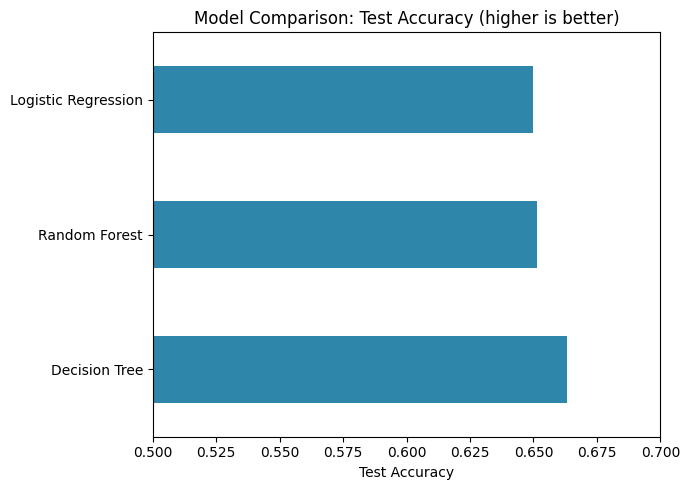

In [4]:
plt.figure(figsize=(7,5))
result_df.plot(kind="barh", color="#2E86AB")
plt.xlabel("Test Accuracy")
plt.title("Model Comparison: Test Accuracy (higher is better)")
plt.xlim(0.5, 0.7)
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=150)
plt.show()


**Result:** all three models land in a tight band (~0.65-0.66), well above the 0.54
baseline, but none of them dramatically outperforms the others. Decision Tree edges out
Logistic Regression and Random Forest slightly here.

This is a pretty common outcome for this kind of tabular data -- most of the predictive
signal comes from a handful of features (roof type, foundation type, plinth area), and once
a model captures those, extra complexity (Random Forest vs a single tuned tree) doesn't buy
much more. The ceiling here is probably the data itself: two buildings with identical
recorded features can still end up in different damage grades depending on things this
dataset doesn't capture (soil conditions, exact distance to the epicenter, construction
quality that wasn't logged, etc.).

**Takeaway:** for this problem, a well-tuned Decision Tree gets you basically all the
accuracy a more complex model would, with the added benefit of being easy to visualize and
explain -- worth keeping in mind before reaching for a heavier model by default.